In [2]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import sim_utils as s_utils
import analysis_utils as a_utils
import g_utils
import h5py
from ratinabox.Environment import Environment
from ratinabox.Agent import Agent
from tqdm import tqdm
from scipy import integrate
from param import Param
import seaborn as sns

In [4]:
params = Param()
lambda_0 = params["lambda0"]

In [7]:
seed = 12
np.random.seed(seed)

total_sim_dur = 45
allo_sim_dur = 5

Env = Environment(
        params = {'dimensionality':'1D',
                'boundary_conditions':'periodic','scale':lambda_0/100})

#allothetic trajectory for the first five seconds
Ag= Agent(Env,
        params = {'dt':0.000025,'speed_mean':0,'speed_std':0}) #0.000025 
Ag.pos=[0]
for i in tqdm(range(int((allo_sim_dur/Ag.dt)+1))): 
        Ag.update()

#rest of the trajectory
Ag.speed_mean = 0.08
Ag.speed_std = 0.08
sim_dur_s_traj = total_sim_dur-allo_sim_dur
for i in tqdm(range(int((sim_dur_s_traj/Ag.dt)+1))): 
        Ag.update()

100%|██████████| 1600001/1600001 [05:29<00:00, 4861.26it/s]


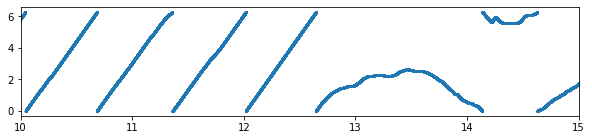

In [13]:
#plotting the trajectory

t=np.array(Ag.history['t'])*1000 #s->ms
pos=np.array(Ag.history['pos'])*100 #m-->cm
vel=np.array(Ag.history['vel']).ravel()/10 #m/s --> cm/ms
traj_start_idx = int((allo_sim_dur)/0.000025)
t=t/1000 #ms-->s
vel=vel*1000
vel[abs(vel)>10]=10 #pin the velocity to 10 since network saturates around 10 rad/s
pos_integrated=integrate.cumulative_trapezoid(vel,t)%(2*np.pi)
plt.figure(figsize=(10,2))
plt.scatter(t[:-1],pos_integrated,s=0.5)
plt.xlim(10,15)
plt.show()

In [11]:
#saving the trajectory for simulations

traj_id ="traj_gov"
fname="input_data/trajectories/traj_{}.hdf5".format(traj_id)
with h5py.File(fname, 'w') as file:
    file.create_dataset("vel_rinb",  data=vel,compression='gzip')
    file.create_dataset("pos_rinb",data=pos_integrated,compression='gzip')
    file.create_dataset("t_rinb",data=t,compression='gzip')
    file.attrs.create("allothetic_dur",allo_sim_dur)
    file.attrs.create("traj_dur",int(total_sim_dur))
    file.attrs.create("traj_params",(Ag.speed_mean,Ag.speed_std,Ag.speed_coherence_time,seed))